In [ ]:
import pandas as pd

#df = pd.read_csv("new_done_data.csv")
train=pd.read_csv("data/new_train.csv")

validation=pd.read_csv("data/new_validation.csv")

trade=pd.read_csv("data/new_trade.csv")

print(train.shape)
print(validation.shape)
print(trade.shape)

In [ ]:
#(1)
import pandas as pd

trade=pd.read_csv("data/new_trade.csv")
trade = trade.sort_values(["datadate","tic"])

trade.index = trade.datadate.factorize()[0]

from env.EnvMultipleStock_trade import StockEnvTrade
env_trade = StockEnvTrade(trade)

from stable_baselines import DDPG

model_ddpg = DDPG.load("trained_models/2026-03-16_15-20-13/DDPG.zip")
#(2)
obs = env_trade.reset()

for i in range(len(trade.index.unique())):

    action, _states = model_ddpg.predict(obs)
    obs, rewards, dones, info = env_trade.step(action)

    #account_memory.append(env_trade.state[0])   # portfolio value

    if dones:
        print("Trading finished")
        break
#(3)        
account_value = env_trade.asset_memory

df_account_value = pd.DataFrame(account_value)
df_account_value.columns = ["account_value"]

#df_account_value.to_csv("results/ddpg_portfolio_value.csv", index=False)

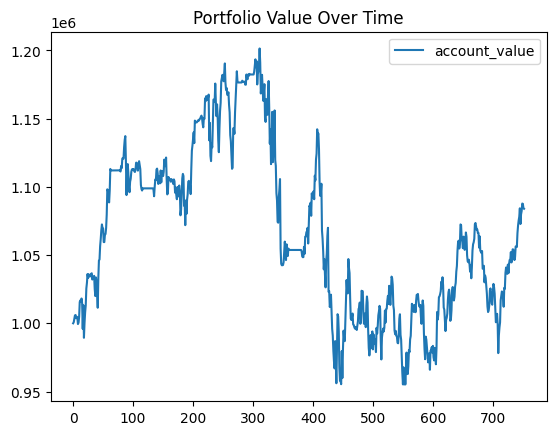

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

df_account_value = pd.read_csv("results/a2c_portfolio_value.csv")
df_account_value.plot()
plt.title("Portfolio Value Over Time")
plt.show()

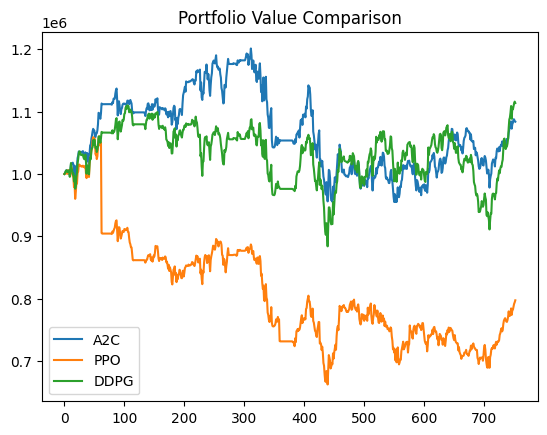

In [2]:
import matplotlib.pyplot as plt

a2c = pd.read_csv("results/a2c_portfolio_value.csv")
ppo = pd.read_csv("results/ppo_portfolio_value.csv")
ddpg = pd.read_csv("results/ddpg_portfolio_value.csv")

plt.plot(a2c.account_value, label="A2C")
plt.plot(ppo.account_value, label="PPO")
plt.plot(ddpg.account_value, label="DDPG")

plt.legend()
plt.title("Portfolio Value Comparison")
plt.show()